# Ingesta de datos para RAG

Lectura de **todos** los `*.pdf` en `corpus/` con pdfplumber. El diccionario `corpus_docs` queda indexado por nombre de archivo: cada valor es la lista `(número_página, texto)`.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import pdfplumber

_cwd = Path.cwd().resolve()


def resolver_repo() -> Path:
    env = os.environ.get("REGATAS_BASE_DIR", "").strip()
    if env:
        base = Path(env).expanduser().resolve()
        if (base / "corpus").is_dir():
            return base
        raise FileNotFoundError(f"REGATAS_BASE_DIR no contiene corpus/: {base}")
    for p in [_cwd, *_cwd.parents]:
        if (p / "corpus").is_dir() and (p / "app.py").is_file():
            return p
    for p in [_cwd, *_cwd.parents]:
        if (p / "corpus").is_dir():
            return p
    raise FileNotFoundError(
        f"No se encontró corpus/ desde cwd={_cwd}. Abrí la raíz del repo o definí REGATAS_BASE_DIR."
    )


def leer_pdf_plumber(path: Path) -> list[tuple[int, str]]:
    filas: list[tuple[int, str]] = []
    with pdfplumber.open(path) as pdf:
        for i, page in enumerate(pdf.pages):
            t = page.extract_text() or ""
            filas.append((i + 1, t))
    return filas


REPO = resolver_repo()
CORPUS_DIR = REPO / "corpus"
pdf_paths = sorted(CORPUS_DIR.glob("*.pdf"))
if not pdf_paths:
    raise FileNotFoundError(f"No hay PDFs en {CORPUS_DIR}")

corpus_docs: dict[str, list[tuple[int, str]]] = {}
for pdf_path in pdf_paths:
    corpus_docs[pdf_path.name] = leer_pdf_plumber(pdf_path)

print("REPO:", REPO)
print("Documentos:", len(corpus_docs))
print()
for name, pages in corpus_docs.items():
    full = "\n\n".join(t for _, t in pages if t.strip())
    print(f"• {name}")
    print(f"    páginas: {len(pages):,}  |  caracteres: {len(full):,}")
print()
# Muestra del primer archivo (orden alfabético)
first_name = pdf_paths[0].name
sample = "\n\n".join(t for _, t in corpus_docs[first_name] if t.strip())[:1200]
print(f"--- Muestra (primeras 1200 chars de {first_name}) ---")
print(sample)

REPO: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/01. Inteligencia Artificial Aplicada/Materias/05. Taller de Trabajo Final/Repositorio/DIIA_trabajo_final
Documentos: 3

• 2025-2028-RRS-with-Changes-and-Corrections.pdf
    páginas: 160  |  caracteres: 233,021
• The-Call-Book-for-Team-Racing-2025-2028.pdf
    páginas: 111  |  caracteres: 121,162
• WS-Case-Book-2025-2028-v2025-07.pdf
    páginas: 328  |  caracteres: 428,527

--- Muestra (primeras 1200 chars de 2025-2028-RRS-with-Changes-and-Corrections.pdf) ---
2025 – 2028
Racing
Rules of
Sailing

RACE SIGNALS
The meanings of visual and sound signals are stated below. An arrow pointing up or down
(
N All races in progress
are abandoned. Return to
the starting area. The
warning signal will be
made 1 minute after
removal unless at that time
the race is abandoned
again or postponed.
 ) means that a visual signal is displayed or removed. A dot ( • ) means a sound; five short
dashes (– – – – –) mean repetitive so

## Longitud por página (caracteres)

Histograma **normalizado** (densidad) + **KDE** (`scipy.stats.gaussian_kde`) por cada PDF. La métrica es `len(texto)` devuelto por pdfplumber en esa página.

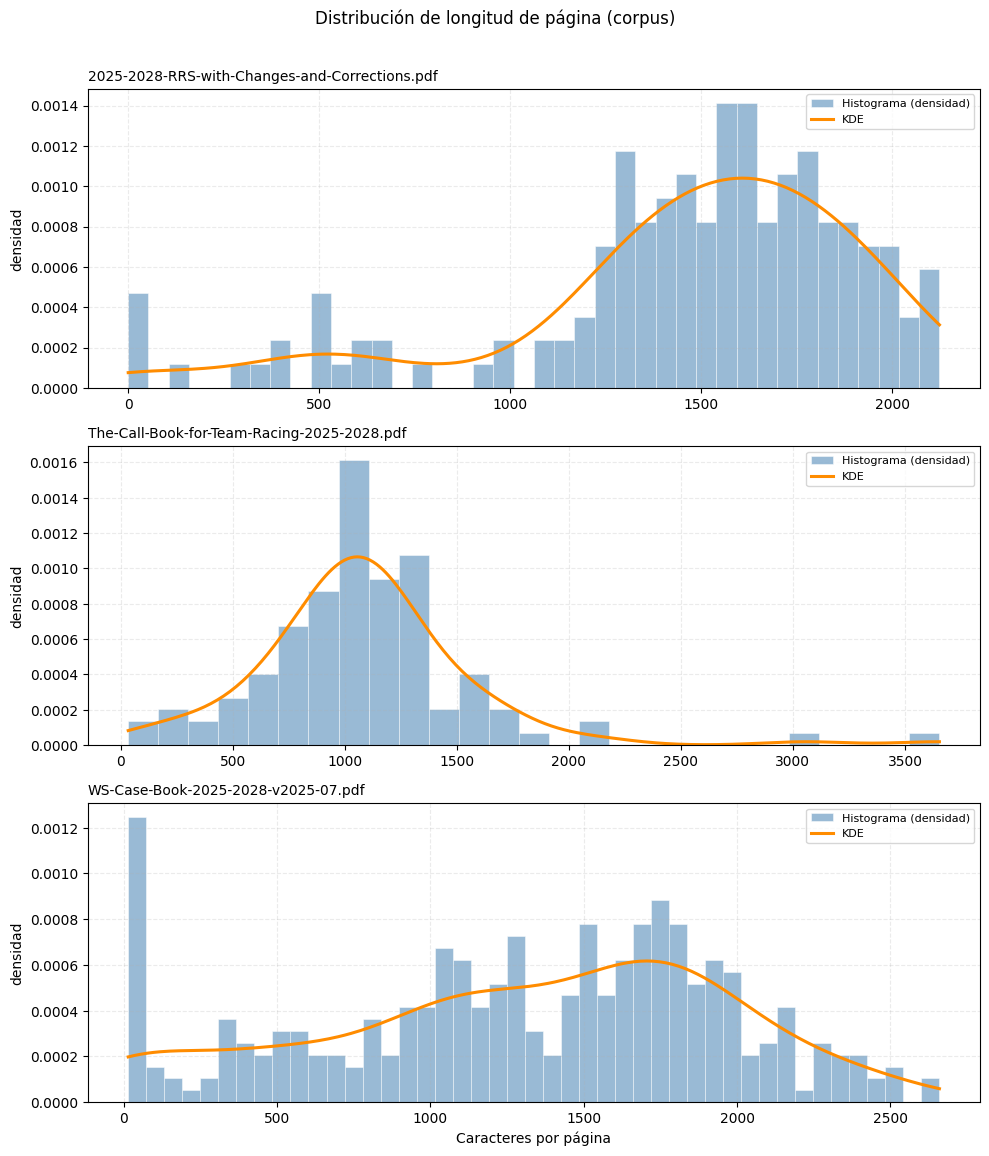

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

if "corpus_docs" not in dir() or not corpus_docs:
    raise RuntimeError("Ejecutá primero la celda que construye corpus_docs.")

fig, axes = plt.subplots(
    len(corpus_docs),
    1,
    figsize=(10, 3.8 * len(corpus_docs)),
    squeeze=False,
)
for ax, (doc_name, pages) in zip(axes.flat, corpus_docs.items()):
    L = np.array([len(t) for _, t in pages], dtype=float)
    n_pages = int(L.size)
    if n_pages == 0:
        ax.set_title(doc_name + " (sin páginas)", fontsize=10, loc="left")
        continue
    n_bins = min(45, max(12, n_pages // 4))
    ax.hist(
        L,
        bins=n_bins,
        density=True,
        alpha=0.55,
        color="steelblue",
        edgecolor="white",
        linewidth=0.6,
        label="Histograma (densidad)",
    )
    if n_pages >= 2 and np.std(L) > 1e-9:
        kde = gaussian_kde(L)
        xs = np.linspace(float(L.min()), float(L.max()), 256)
        ax.plot(xs, kde(xs), color="darkorange", lw=2.2, label="KDE")
    else:
        ax.axvline(float(L[0]) if n_pages else 0, color="darkorange", lw=2.2, label="KDE (1 página)")
    ax.set_title(doc_name, fontsize=10, loc="left")
    ax.set_ylabel("densidad")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.25, linestyle="--")

axes.flat[-1].set_xlabel("Caracteres por página")
plt.suptitle("Distribución de longitud de página (corpus)", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## Páginas por tipo de documento

Barras según **tipo** inferido del nombre del PDF (RRS, Case Book, Call Book Team Racing). Si agregás más archivos del mismo tipo, las páginas se **suman**.

Mapeo archivo → tipo:
  The-Call-Book-for-Team-Racing-2025-2028.pdf  →  Call Book (Team Racing)
  WS-Case-Book-2025-2028-v2025-07.pdf  →  Case Book
  2025-2028-RRS-with-Changes-and-Corrections.pdf  →  RRS



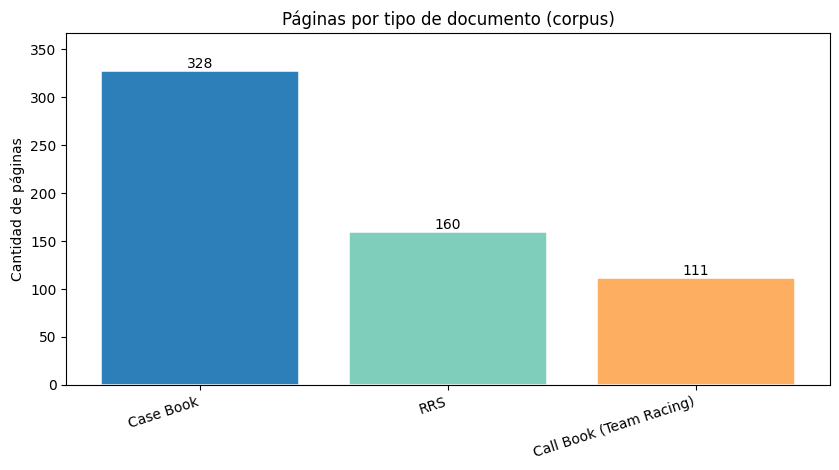

In [3]:
from collections import defaultdict

import matplotlib.pyplot as plt

if "corpus_docs" not in dir() or not corpus_docs:
    raise RuntimeError("Ejecutá primero la celda que construye corpus_docs.")


def tipo_documento(filename: str) -> str:
    """Etiqueta de negocio a partir del nombre de archivo (ajustá reglas si sumás PDFs nuevos)."""
    n = filename.lower()
    if "rrs" in n:
        return "RRS"
    if "call-book" in n or "team-racing" in n:
        return "Call Book (Team Racing)"
    if "case-book" in n or n.startswith("ws-case"):
        return "Case Book"
    return filename


paginas_por_tipo: dict[str, int] = defaultdict(int)
archivos_por_tipo: dict[str, list[str]] = defaultdict(list)
for fname, pages in corpus_docs.items():
    t = tipo_documento(fname)
    paginas_por_tipo[t] += len(pages)
    archivos_por_tipo[t].append(fname)

print("Mapeo archivo → tipo:")
for t in sorted(archivos_por_tipo.keys()):
    for f in sorted(archivos_por_tipo[t]):
        print(f"  {f}  →  {t}")
print()

tipos_ord = sorted(paginas_por_tipo.keys(), key=lambda k: (-paginas_por_tipo[k], k))
cuentas = [paginas_por_tipo[t] for t in tipos_ord]
colores = ["#2c7fb8", "#7fcdbb", "#fdae61", "#bc80bd", "#8da0cb"]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    tipos_ord,
    cuentas,
    color=colores[: len(tipos_ord)],
    edgecolor="white",
    linewidth=1.1,
)
ax.set_ylabel("Cantidad de páginas")
ax.set_title("Páginas por tipo de documento (corpus)")
ax.set_ylim(0, max(cuentas) * 1.12 if cuentas else 1)
for bar, n in zip(bars, cuentas):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{n:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="medium",
    )
plt.xticks(rotation=18, ha="right")
plt.tight_layout()
plt.show()

## Caracteres por bloques de 10 páginas (pypdf vs pdfplumber limpio)

Para cada PDF se suman los **caracteres** de las páginas agrupadas de a **10** (etiqueta con rango real de números de página, p. ej. `p.1–10`, `p.11–20`).

- **Antes (pypdf):** `len(texto)` del texto extraído con **pypdf** (`PdfReader`), página a página. Es independiente de pdfplumber y permite ver diferencias entre extractores. Un PDF no guarda un conteo de caracteres sin pasar por algún extractor; esta barra es la forma práctica de mostrar “sin pdfplumber” usando otro motor del ecosistema Python.
- **Después (pdfplumber, limpio):** texto de **pdfplumber** (misma fuente que `corpus_docs`) con (1) el mismo criterio que `regatas_assistant/ingestion.py`: colapsar espacios/saltos a un solo espacio y `strip`; (2) retirar candidatos a **referencia bibliográfica** `\b[A-Z]{3} YYYY/NN…\b` (ilustrativo, alineado a `BL-2026-002`).

Si más adelante la limpieza del pipeline cambia, actualizá la función `limpiar_pagina` en la celda de código.


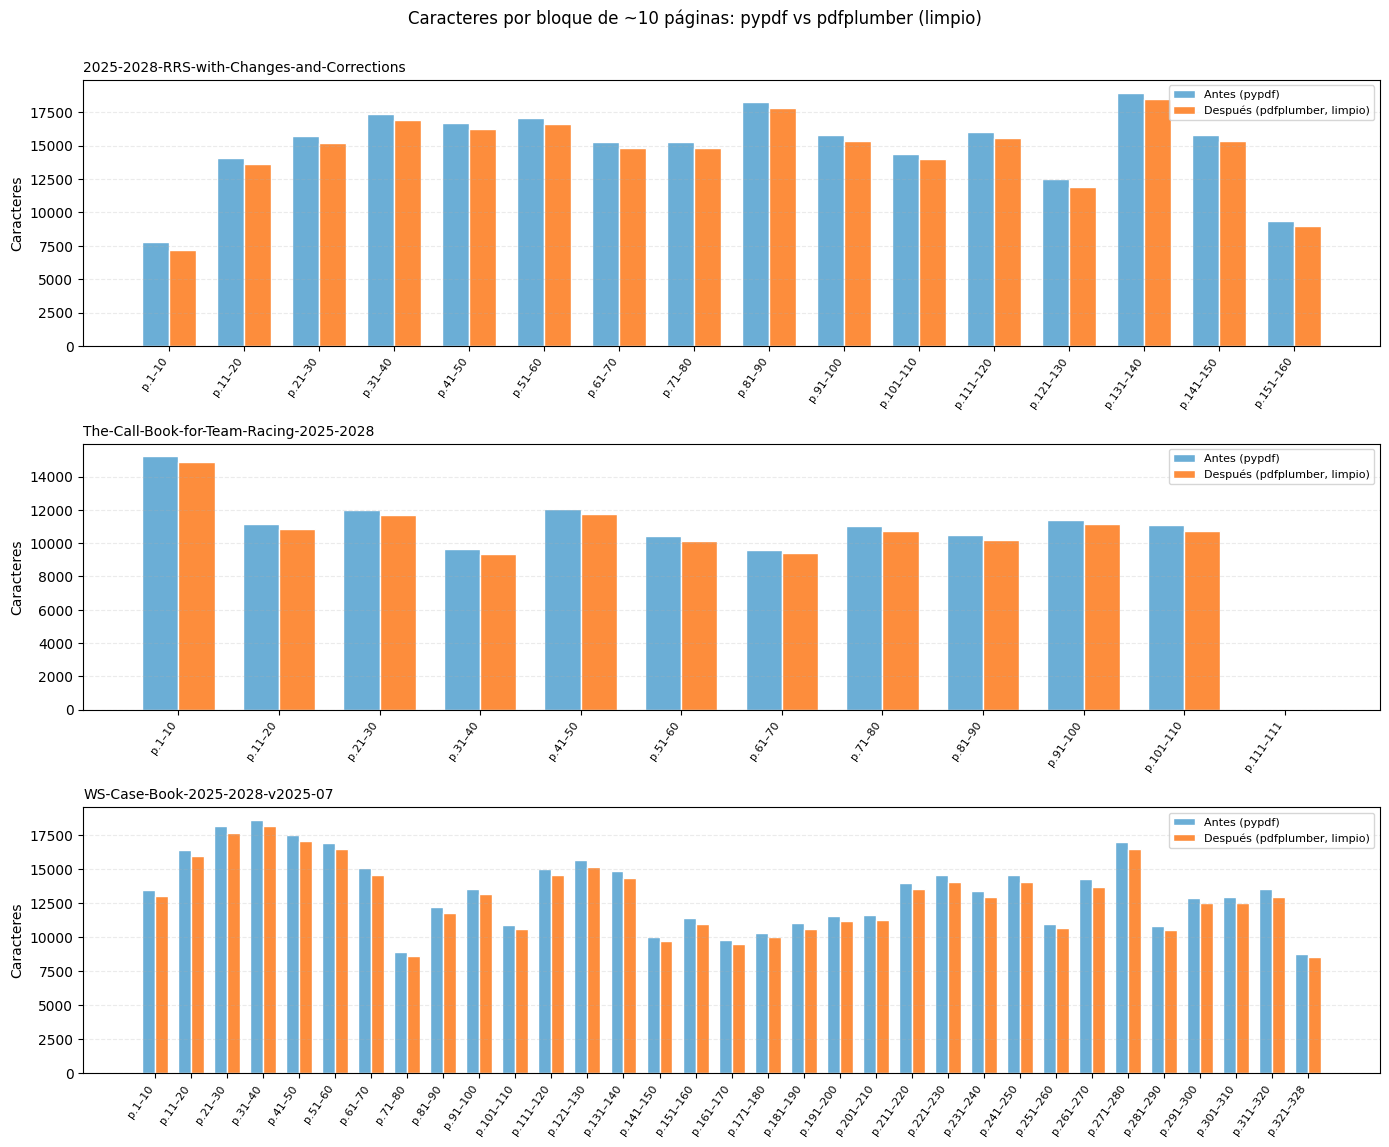

In [4]:
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pypdf import PdfReader

if "corpus_docs" not in dir() or not corpus_docs:
    raise RuntimeError("Ejecutá primero la celda que construye corpus_docs.")
if "CORPUS_DIR" not in dir():
    raise RuntimeError("Ejecutá primero la celda que define CORPUS_DIR (carga del corpus).")

PAGE_GROUP = 10
RE_BIB = re.compile(r"\b[A-Z]{3}\s+\d{4}/\d{2,}\b")


def limpiar_pagina(texto: str) -> str:
    """Espacios como en ingestion.py + retirada ilustrativa de refs tipo GBR 1962/25."""
    t = re.sub(r"\s+", " ", texto).strip()
    t = RE_BIB.sub("", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def texto_por_pagina_pypdf(pdf_path: Path) -> dict[int, str]:
    """Texto por número de página (1-based), extraído con pypdf (sin pdfplumber)."""
    r = PdfReader(str(pdf_path))
    out: dict[int, str] = {}
    for i, page in enumerate(r.pages):
        try:
            t = page.extract_text()
        except Exception:
            t = None
        out[i + 1] = t if t is not None else ""
    return out


def caracteres_por_bloque_pypdf(
    ref_pages: list[tuple[int, str]], pypdf_by_page: dict[int, str]
) -> tuple[list[str], list[int]]:
    """Mismos bloques que en corpus_docs; suma len(texto) según pypdf por nº de página."""
    pages_sorted = sorted(ref_pages, key=lambda x: x[0])
    suma: dict[int, int] = defaultdict(int)
    nums: dict[int, list[int]] = defaultdict(list)
    for pnum, _ in pages_sorted:
        t = pypdf_by_page.get(pnum, "")
        b = (pnum - 1) // PAGE_GROUP
        suma[b] += len(t)
        nums[b].append(pnum)
    if not suma:
        return [], []
    labels: list[str] = []
    vals: list[int] = []
    for b in sorted(suma.keys()):
        lo, hi = min(nums[b]), max(nums[b])
        labels.append(f"p.{lo}–{hi}")
        vals.append(suma[b])
    return labels, vals


def caracteres_por_bloque_plumber_limpio(
    pages: list[tuple[int, str]],
) -> tuple[list[str], list[int]]:
    pages_sorted = sorted(pages, key=lambda x: x[0])
    suma: dict[int, int] = defaultdict(int)
    nums: dict[int, list[int]] = defaultdict(list)
    for pnum, t in pages_sorted:
        b = (pnum - 1) // PAGE_GROUP
        s = limpiar_pagina(t)
        suma[b] += len(s)
        nums[b].append(pnum)
    if not suma:
        return [], []
    labels: list[str] = []
    vals: list[int] = []
    for b in sorted(suma.keys()):
        lo, hi = min(nums[b]), max(nums[b])
        labels.append(f"p.{lo}–{hi}")
        vals.append(suma[b])
    return labels, vals


n_docs = len(corpus_docs)
fig, axes = plt.subplots(n_docs, 1, figsize=(14, 3.8 * n_docs), squeeze=False)

for ax, (fname, pages) in zip(axes.flat, sorted(corpus_docs.items())):
    py_map = texto_por_pagina_pypdf(CORPUS_DIR / fname)
    n_py = len(py_map)
    n_pb = len(pages)
    if n_py != n_pb:
        print(
            f"[aviso] {fname}: pypdf {n_py} páginas vs pdfplumber {n_pb} "
            "(bloques alineados por nº de página; faltan conteos pypdf si aplica)."
        )
    lb, antes = caracteres_por_bloque_pypdf(pages, py_map)
    _lb2, despues = caracteres_por_bloque_plumber_limpio(pages)
    assert lb == _lb2
    x = np.arange(len(lb))
    w = 0.36
    ax.bar(x - w / 2, antes, width=w, label="Antes (pypdf)", color="#6baed6", edgecolor="white")
    ax.bar(
        x + w / 2,
        despues,
        width=w,
        label="Después (pdfplumber, limpio)",
        color="#fd8d3c",
        edgecolor="white",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(lb, rotation=55, ha="right", fontsize=8)
    ax.set_ylabel("Caracteres")
    ax.set_title(fname.replace(".pdf", ""), loc="left", fontsize=10)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")

plt.suptitle(
    f"Caracteres por bloque de ~{PAGE_GROUP} páginas: pypdf vs pdfplumber (limpio)",
    y=1.002,
    fontsize=12,
)
plt.tight_layout()
plt.show()


## Stop words (inglés) por documento

Porcentaje de **tokens alfabéticos** (`[A-Za-z]+` en minúsculas) que aparecen en `regatas_assistant/stopwords_en.txt` (orden alfabético).

**Lista reelaborada:** base **scikit-learn** `ENGLISH_STOP_WORDS` (≈310 términos en archivo tras ajustes), **una palabra por línea**. Para el corpus normativo / Team Racing **no** se filtran como stop word: `call`, `must`, `may`, `will`, `can`, `cannot`, `should`. Se eliminó el duplicado ortográfico `amoungst` (queda `amongst`). Para volver a generar el `.txt` hace falta `scikit-learn` (línea comentada en `requirements.txt`).

Interpretación: compará el % entre PDFs del corpus; no uses un umbral absoluto “bueno/malo”.

2025-2028-RRS-with-Changes-and-Corrections.pdf
  tokens: 39,543  |  stop words: 18,642  |  47.14 %
The-Call-Book-for-Team-Racing-2025-2028.pdf
  tokens: 22,112  |  stop words: 9,765  |  44.16 %
WS-Case-Book-2025-2028-v2025-07.pdf
  tokens: 74,987  |  stop words: 36,965  |  49.30 %


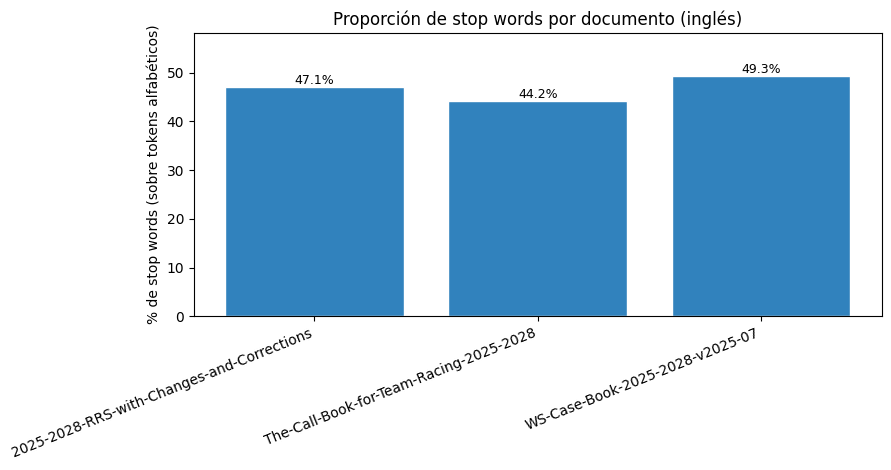

In [5]:
import re
from pathlib import Path

import matplotlib.pyplot as plt

if "corpus_docs" not in dir() or not corpus_docs:
    raise RuntimeError("Ejecutá primero la celda que construye corpus_docs.")
if "REPO" not in dir():
    raise RuntimeError("Falta REPO; ejecutá la celda de carga del corpus.")

STOPWORDS_PATH = REPO / "regatas_assistant" / "stopwords_en.txt"
if not STOPWORDS_PATH.is_file():
    raise FileNotFoundError(f"No está {STOPWORDS_PATH}")

raw_sw = STOPWORDS_PATH.read_text(encoding="utf-8")
stopwords_en = {
    line.strip().lower()
    for line in raw_sw.splitlines()
    if line.strip() and not line.lstrip().startswith("#")
}
_TOKEN_RE = re.compile(r"[A-Za-z]+")


def tokens_alfabeticos(texto: str) -> list[str]:
    return [m.group(0).lower() for m in _TOKEN_RE.finditer(texto)]


def metricas_stopwords(texto_completo: str) -> tuple[int, int, float]:
    toks = tokens_alfabeticos(texto_completo)
    n = len(toks)
    if n == 0:
        return 0, 0, 0.0
    sw = sum(1 for t in toks if t in stopwords_en)
    pct = 100.0 * sw / n
    return sw, n, pct


filas: list[tuple[str, int, int, float]] = []
for fname, pages in sorted(corpus_docs.items()):
    texto = "\n".join(t for _, t in pages)
    sw, n, pct = metricas_stopwords(texto)
    filas.append((fname, sw, n, pct))
    print(f"{fname}\n  tokens: {n:,}  |  stop words: {sw:,}  |  {pct:.2f} %")

nombres = [f[0] for f in filas]
pcts = [f[3] for f in filas]

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(
    range(len(nombres)),
    pcts,
    color="#3182bd",
    edgecolor="white",
    linewidth=1,
)
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels([n.replace(".pdf", "") for n in nombres], rotation=22, ha="right")
ax.set_ylabel("% de stop words (sobre tokens alfabéticos)")
ax.set_title("Proporción de stop words por documento (inglés)")
ax.set_ylim(0, max(pcts) * 1.18 if pcts else 1)
for bar, pct in zip(bars, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="medium",
    )
plt.tight_layout()
plt.show()

## Cobertura con ventana de 512 tokens

**Interpretación “¿qué % del documento cabe en 512 tokens?”**  
Si solo podés pasar **una** ventana de contexto de 512 tokens, la fracción del texto (en tokens) que ves es:

$$\frac{\min(512,\; T)}{T} \times 100\%$$

donde \(T\) es el **total de tokens** del PDF. Si \(T > 512\), el resto exige **más ventanas** (chunking).

**Tokenizer (Qwen):** Hugging Face **`transformers.AutoTokenizer`** con el mismo `model_id` que usarás en inferencia (por defecto `Qwen/Qwen2.5-0.5B-Instruct`). Podés fijar **`REGATAS_QWEN_MODEL_ID`** en el entorno para que coincida exactamente con tu checkpoint (p. ej. `Qwen/Qwen2.5-7B-Instruct`); el vocabulario suele ser el mismo dentro de la misma familia, pero conviene usar el mismo id que en producción.

La primera ejecución puede **descargar** archivos del tokenizer desde Hugging Face.

**Salida en la celda siguiente:**  
- **Gráfico** — tokens totales por documento (texto completo, `encode` sin tokens especiales).  
- **Gráfico** — % del documento que entra en **una** ventana de 512 tokens.  
- **Consola** — también se imprime el % de páginas con ≤512 tokens por página (sin gráfico).

Tokenizer Qwen: Qwen/Qwen2.5-14B-Instruct

2025-2028-RRS-with-Changes-and-Corrections.pdf
  tokens totales (doc): 58,199
  % del doc en UNA ventana de 512: 0.88%
  páginas con ≤512 tokens: 159/160  →  99.4%

The-Call-Book-for-Team-Racing-2025-2028.pdf
  tokens totales (doc): 32,921
  % del doc en UNA ventana de 512: 1.56%
  páginas con ≤512 tokens: 108/111  →  97.3%

WS-Case-Book-2025-2028-v2025-07.pdf
  tokens totales (doc): 107,973
  % del doc en UNA ventana de 512: 0.47%
  páginas con ≤512 tokens: 297/328  →  90.5%



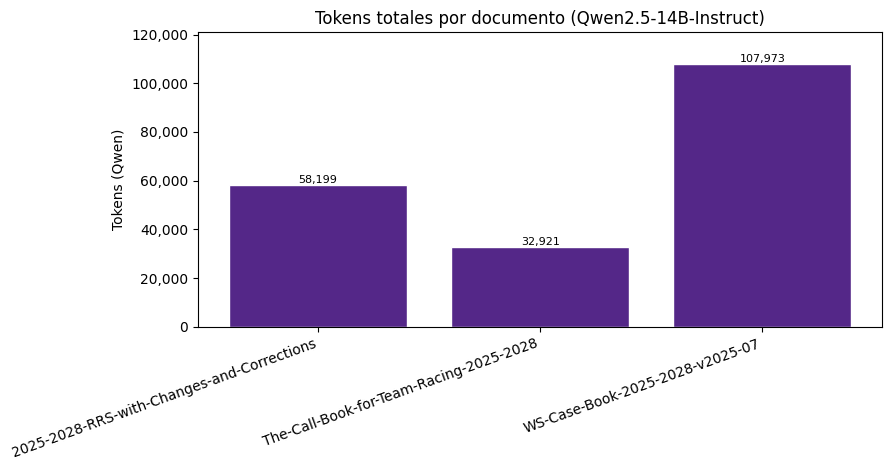

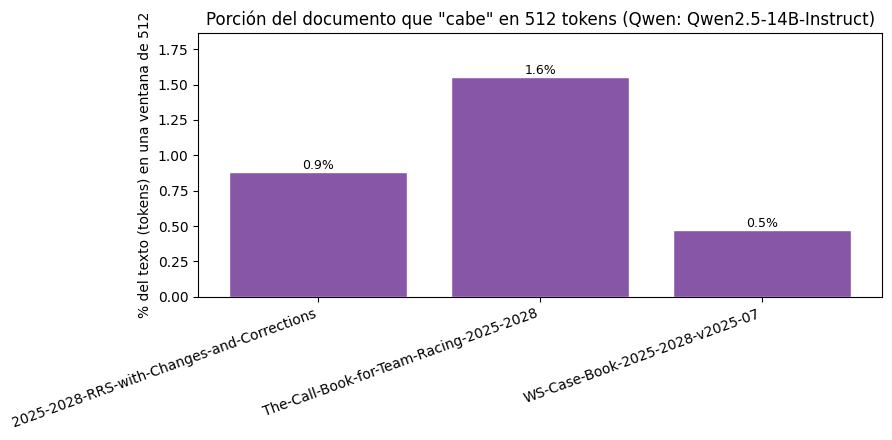

In [6]:
import os

import matplotlib.pyplot as plt
from transformers import AutoTokenizer

if "corpus_docs" not in dir() or not corpus_docs:
    raise RuntimeError("Ejecutá primero la celda que construye corpus_docs.")

MAX_TOKENS = 512
QWEN_MODEL_ID = os.environ.get(
    "REGATAS_QWEN_MODEL_ID",
    "Qwen/Qwen2.5-14B-Instruct",
)

tokenizer = AutoTokenizer.from_pretrained(
    QWEN_MODEL_ID,
    trust_remote_code=True,
)
print(f"Tokenizer Qwen: {QWEN_MODEL_ID}\n")


def n_tokens_qwen(texto: str) -> int:
    # Sin tokens especiales: cuenta solo el texto (típico para estimar chunking)
    return len(tokenizer.encode(texto, add_special_tokens=False))


filas_512: list[tuple[str, int, float, float, int, int]] = []
for fname, pages in sorted(corpus_docs.items()):
    texto_completo = "\n".join(t for _, t in pages)
    T = n_tokens_qwen(texto_completo)
    pct_una = 100.0 * min(MAX_TOKENS, T) / T if T else 0.0

    pag_ok = 0
    for _, t in pages:
        if n_tokens_qwen(t) <= MAX_TOKENS:
            pag_ok += 1
    n_pag = len(pages)
    pct_pag = 100.0 * pag_ok / n_pag if n_pag else 0.0

    filas_512.append((fname, T, pct_una, pct_pag, pag_ok, n_pag))
    print(f"{fname}")
    print(f"  tokens totales (doc): {T:,}")
    print(f"  % del doc en UNA ventana de {MAX_TOKENS}: {pct_una:.2f}%")
    print(f"  páginas con ≤{MAX_TOKENS} tokens: {pag_ok}/{n_pag}  →  {pct_pag:.1f}%")
    print()

labels = [f[0].replace(".pdf", "") for f in filas_512]
tokens_doc = [f[1] for f in filas_512]
vals = [f[2] for f in filas_512]

short_id = QWEN_MODEL_ID.split("/")[-1]

# Tokens del documento completo (concatenación de páginas, sin tokens especiales)
fig0, ax0 = plt.subplots(figsize=(9, 4.8))
bars0 = ax0.bar(
    range(len(labels)),
    tokens_doc,
    color="#542788",
    edgecolor="white",
    linewidth=1,
)
ax0.set_xticks(range(len(labels)))
ax0.set_xticklabels(labels, rotation=20, ha="right")
ax0.set_ylabel("Tokens (Qwen)")
ax0.set_title(f"Tokens totales por documento ({short_id})")
ymax_tok = max(tokens_doc) if tokens_doc else 1
ax0.set_ylim(0, ymax_tok * 1.12)
ax0.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
for bar, n in zip(bars0, tokens_doc):
    ax0.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{n:,}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0,
    )
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(range(len(labels)), vals, color="#8856a7", edgecolor="white", linewidth=1)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel(f"% del texto (tokens) en una ventana de {MAX_TOKENS}")
ax.set_title(
    f'Porción del documento que "cabe" en {MAX_TOKENS} tokens (Qwen: {short_id})'
)
ax.set_ylim(0, min(105, max(vals) * 1.2 if vals else 1))
for bar, v in zip(bars, vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{v:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

## Brecha producción (caracteres) vs tokenizer (tokens)

Los fragmentos de **`load_corpus_chunks`** usan el mismo criterio que producción: troceo **por página** en **caracteres** (`chunk_size` / `chunk_overlap` de `Settings`, por defecto 900 / 120). Esta sección mide cuántos de esos chunks **superan** un techo típico de contexto para embeddings (512 tokens Qwen) y resume la relación **caracteres → tokens**.

**Prerrequisito:** celda de **Cobertura con ventana de 512 tokens** (define `tokenizer` y `QWEN_MODEL_ID`) o dejar que la celda siguiente cargue el tokenizer si hace falta.

Ingesta producción: chunk_size=900 chars, overlap=120 chars (por página, pypdf)
Chunks totales: 1,247  |  techo embeddings: 512 tokens Qwen
Tokenizer: Qwen/Qwen2.5-14B-Instruct

archivo | chunks | p50 tok | p90 tok | p95 tok | % chunks >512 | chars/chunk (media) | tok/char
-----------------------------------------------------------------------------------------------
2025-2028-RRS-with-Cha |   353 |     194 |     229 |     237 |    0.0% |      726 | 0.237
The-Call-Book-for-Team |   200 |     198 |     241 |     247 |    0.5% |      659 | 0.257
WS-Case-Book-2025-2028 |   694 |     193 |     225 |     236 |    0.0% |      680 | 0.236
-----------------------------------------------------------------------------------------------
GLOBAL                 | 1,247 |     193 |     231 |     238 |    0.1% |      689 | 0.240


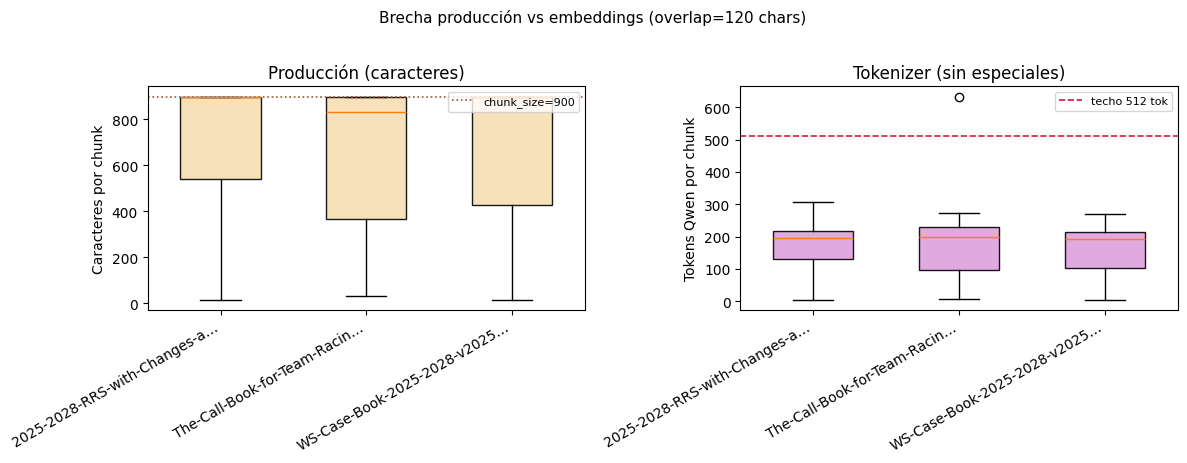

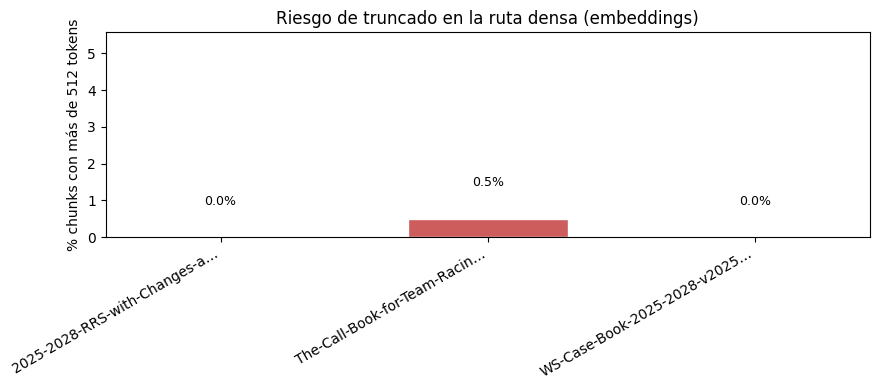

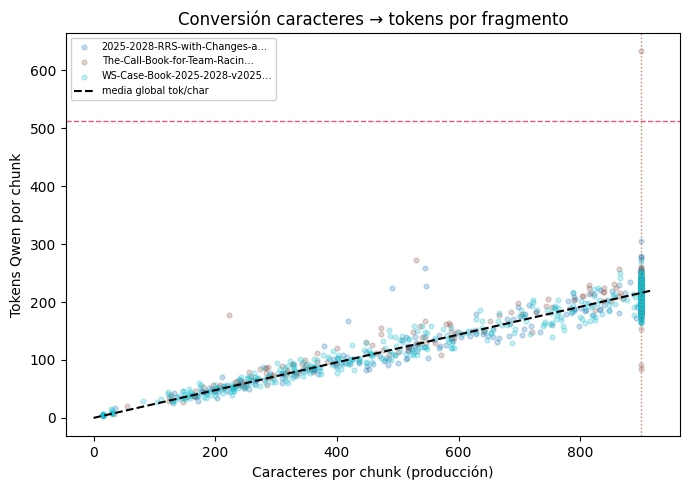

In [7]:
import os
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer

_cwd = Path.cwd().resolve()
if "REPO" in dir():
    _root = Path(REPO).resolve()
else:
    _root = None
    for p in [_cwd, *_cwd.parents]:
        if (p / "regatas_assistant").is_dir() and (p / "app.py").is_file():
            _root = p
            break
    if _root is None:
        raise RuntimeError(
            "No se encontró la raíz del repo. Ejecutá la celda inicial o abrí el proyecto desde el repo."
        )
_rp = str(_root)
if _rp not in sys.path:
    sys.path.insert(0, _rp)

from regatas_assistant.config import Settings
from regatas_assistant.ingestion import load_corpus_chunks

MAX_EMB_TOKS = 512

corpus_names = tuple(sorted(p.name for p in (_root / "corpus").glob("*.pdf")))
if not corpus_names:
    raise FileNotFoundError(f"No hay PDFs en {_root / 'corpus'}")

settings = Settings(base_dir=_root, corpus_filenames=corpus_names)
chunks = load_corpus_chunks(settings)
if not chunks:
    raise RuntimeError("No se obtuvieron fragmentos; revisá el corpus.")

if "tokenizer" not in dir():
    QWEN_MODEL_ID = os.environ.get(
        "REGATAS_QWEN_MODEL_ID",
        "Qwen/Qwen2.5-14B-Instruct",
    )
    tokenizer = AutoTokenizer.from_pretrained(
        QWEN_MODEL_ID,
        trust_remote_code=True,
    )
    print(f"Tokenizer Qwen cargado: {QWEN_MODEL_ID}\n")
else:
    QWEN_MODEL_ID = globals().get("QWEN_MODEL_ID", "(tokenizer previo)")


def n_tokens_qwen_chunk(text: str) -> int:
    return len(tokenizer.encode(text, add_special_tokens=False))


char_lens: list[int] = []
tok_lens: list[int] = []
by_file_chars: dict[str, list[int]] = defaultdict(list)
by_file_toks: dict[str, list[int]] = defaultdict(list)

for c in chunks:
    nc = len(c.text)
    nt = n_tokens_qwen_chunk(c.text)
    char_lens.append(nc)
    tok_lens.append(nt)
    by_file_chars[c.source_file].append(nc)
    by_file_toks[c.source_file].append(nt)

files_sorted = sorted(by_file_chars.keys())
labels_short = [n[:28] + "…" if len(n) > 28 else n for n in files_sorted]

print(
    f"Ingesta producción: chunk_size={settings.chunk_size} chars, "
    f"overlap={settings.chunk_overlap} chars (por página, pypdf)\n"
    f"Chunks totales: {len(chunks):,}  |  techo embeddings: {MAX_EMB_TOKS} tokens Qwen\n"
    f"Tokenizer: {QWEN_MODEL_ID}\n"
)
print("archivo | chunks | p50 tok | p90 tok | p95 tok | % chunks >512 | chars/chunk (media) | tok/char")
print("-" * 95)

pct_over_by_file: list[float] = []
for fname in files_sorted:
    tq = np.array(by_file_toks[fname], dtype=float)
    ch = np.array(by_file_chars[fname], dtype=float)
    pct_over = 100.0 * (tq > MAX_EMB_TOKS).sum() / len(tq) if len(tq) else 0.0
    pct_over_by_file.append(pct_over)
    ratio = float(tq.mean() / ch.mean()) if ch.mean() else 0.0
    print(
        f"{fname[:22]:<22} | {len(tq):5,} | {np.percentile(tq, 50):7.0f} | "
        f"{np.percentile(tq, 90):7.0f} | {np.percentile(tq, 95):7.0f} | "
        f"{pct_over:6.1f}% | {ch.mean():8.0f} | {ratio:.3f}"
    )

tq_all = np.array(tok_lens, dtype=float)
ch_all = np.array(char_lens, dtype=float)
print("-" * 95)
print(
    f"{'GLOBAL':<22} | {len(tq_all):5,} | {np.percentile(tq_all, 50):7.0f} | "
    f"{np.percentile(tq_all, 90):7.0f} | {np.percentile(tq_all, 95):7.0f} | "
    f"{100 * (tq_all > MAX_EMB_TOKS).sum() / len(tq_all):6.1f}% | {ch_all.mean():8.0f} | "
    f"{tq_all.mean() / ch_all.mean():.3f}"
)

# --- 1) Caracteres vs tokens por chunk (cajas por PDF)
data_chars = [by_file_chars[f] for f in files_sorted]
data_toks = [by_file_toks[f] for f in files_sorted]
pos = np.arange(1, len(files_sorted) + 1)

fig, (ax_c, ax_t) = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
bp_c = ax_c.boxplot(
    data_chars,
    positions=pos,
    widths=0.55,
    patch_artist=True,
    showfliers=True,
)
for patch in bp_c["boxes"]:
    patch.set_facecolor("wheat")
    patch.set_alpha(0.9)
ax_c.axhline(settings.chunk_size, color="sienna", linestyle=":", linewidth=1.2, label=f"chunk_size={settings.chunk_size}")
ax_c.set_ylabel("Caracteres por chunk")
ax_c.set_title("Producción (caracteres)")
ax_c.legend(loc="upper right", fontsize=8)

bp_t = ax_t.boxplot(
    data_toks,
    positions=pos,
    widths=0.55,
    patch_artist=True,
    showfliers=True,
)
for patch in bp_t["boxes"]:
    patch.set_facecolor("plum")
    patch.set_alpha(0.9)
ax_t.axhline(MAX_EMB_TOKS, color="crimson", linestyle="--", linewidth=1.2, label=f"techo {MAX_EMB_TOKS} tok")
ax_t.set_ylabel("Tokens Qwen por chunk")
ax_t.set_title("Tokenizer (sin especiales)")
ax_t.legend(loc="upper right", fontsize=8)

for ax in (ax_c, ax_t):
    ax.set_xticks(pos)
    ax.set_xticklabels(labels_short, rotation=30, ha="right")

fig.suptitle(
    f"Brecha producción vs embeddings (overlap={settings.chunk_overlap} chars)",
    y=1.02,
    fontsize=11,
)
fig.tight_layout()
plt.show()

# --- 2) % de chunks que superan el techo de tokens
fig2, ax2 = plt.subplots(figsize=(9, 4))
bars = ax2.bar(pos, pct_over_by_file, color="indianred", edgecolor="white", width=0.6)
ax2.set_xticks(pos)
ax2.set_xticklabels(labels_short, rotation=30, ha="right")
ax2.set_ylabel(f"% chunks con más de {MAX_EMB_TOKS} tokens")
ax2.set_ylim(0, min(100, max(pct_over_by_file) * 1.15 + 5) if pct_over_by_file else 100)
ax2.set_title("Riesgo de truncado en la ruta densa (embeddings)")
for bar, pct in zip(bars, pct_over_by_file):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig2.tight_layout()
plt.show()

# --- 3) Relación chars → tokens (global)
fig3, ax3 = plt.subplots(figsize=(7, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(files_sorted)))
for i, fname in enumerate(files_sorted):
    ax3.scatter(
        by_file_chars[fname],
        by_file_toks[fname],
        alpha=0.25,
        s=12,
        c=[colors[i]],
        label=labels_short[i],
    )
xs = np.linspace(0, max(char_lens) * 1.02, 50)
ax3.plot(xs, xs * (tq_all.mean() / ch_all.mean()), "k--", lw=1.5, label="media global tok/char")
ax3.axhline(MAX_EMB_TOKS, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
ax3.axvline(settings.chunk_size, color="sienna", linestyle=":", linewidth=1, alpha=0.7)
ax3.set_xlabel("Caracteres por chunk (producción)")
ax3.set_ylabel("Tokens Qwen por chunk")
ax3.set_title("Conversión caracteres → tokens por fragmento")
ax3.legend(loc="upper left", fontsize=7, framealpha=0.9)
fig3.tight_layout()
plt.show()

## Estructura y segmentación

Tres vistas alineadas al análisis de cómo quedará el corpus troceado y qué señales normativas tiene el texto.

1. **Chunks en tokens (ventana deslizante):** sobre el texto **limpio** (mismo criterio que la celda de bloques de 10 páginas: espacios colapsados + retirada de refs tipo `GBR 1962/25`), se tokeniza con el **mismo tokenizer Qwen** que la celda de 512 tokens y se aplica ventana **`CHUNK_TOKENS` / `OVERLAP_TOKENS`** sobre el documento completo. Gráfico de **cajas** de longitudes (tokens) por PDF, barras de **cantidad de chunks**, e impresión de **p50 / p90 / p95** por documento.

2. **Solapamiento efectivo:** con esa ventana, \(\%\) de tokens “extra” respecto del stream único: \(100 \times (\sum_i |C_i| - T) / \sum_i |C_i|\), donde \(T\) es el total de tokens del doc y \(|C_i|\) la longitud de cada chunk (mide cuánto peso del índice RAG es redundancia por solape).

3. **Delimitadores de dominio:** conteos por documento con regex tipo **PoC**: `CASE` + número, `Rule` + número (insensible a mayúsculas). Barras agrupadas para comparar PDFs.

**Nota:** En producción, `regatas_assistant/ingestion.py` trocea **por página** en **caracteres** (`chunk_size` / `chunk_overlap` en `Settings`). Esta sección es **EDA en tokens** para calibrar ventana de contexto/embeddings; podés cambiar `CHUNK_TOKENS` y `OVERLAP_TOKENS` abajo.

**Prerrequisitos:** celda que define `corpus_docs`. Para el tokenizer, ejecutá antes la celda de **Cobertura con ventana de 512 tokens** o dejá que la celda siguiente cargue `AutoTokenizer` si hace falta.

Ventana: 512 tokens, solape efectivo 128 (stride 384).

documento | p50 | p90 | p95 | n_chunks
------------------------------------------------------------------------
2025-2028-RRS-with-Changes-and-Correctio | 512 | 512 | 512 | 144
The-Call-Book-for-Team-Racing-2025-2028. | 512 | 512 | 512 | 81
WS-Case-Book-2025-2028-v2025-07.pdf      | 512 | 512 | 512 | 263


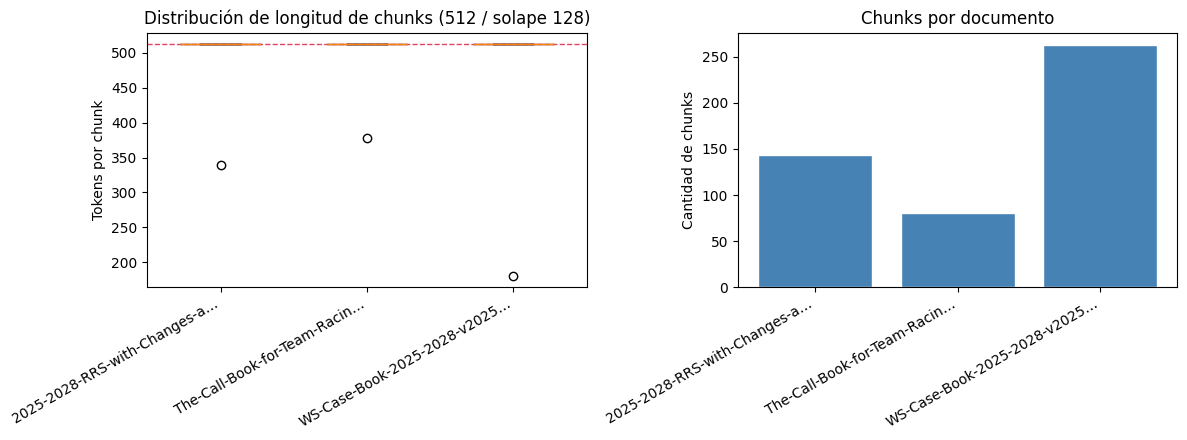

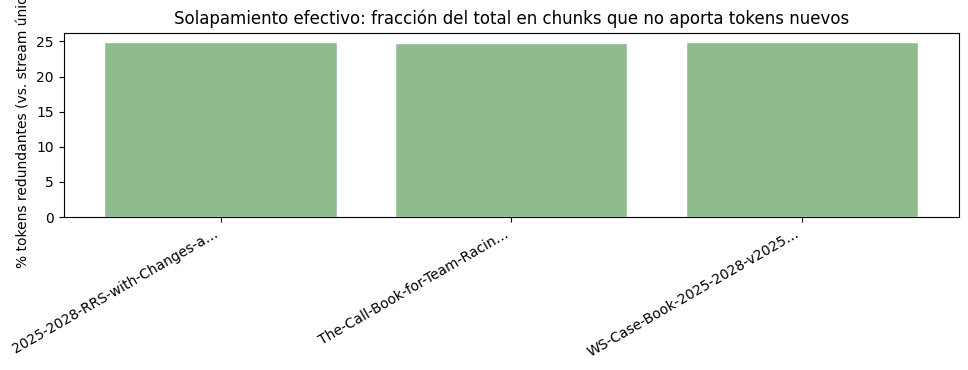

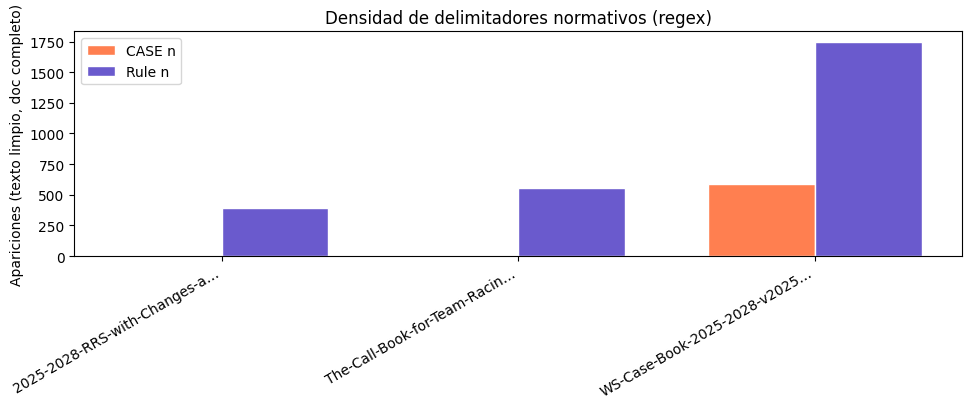

In [8]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer

if "corpus_docs" not in dir() or not corpus_docs:
    raise RuntimeError("Ejecutá primero la celda que construye corpus_docs.")

CHUNK_TOKENS = 512
OVERLAP_TOKENS = 128

RE_BIB = re.compile(r"\b[A-Z]{3}\s+\d{4}/\d{2,}\b")


def _limpiar_pagina_estructura(texto: str) -> str:
    t = re.sub(r"\s+", " ", texto).strip()
    t = RE_BIB.sub("", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def texto_doc_limpio(pages: list[tuple[int, str]]) -> str:
    return "\n".join(
        _limpiar_pagina_estructura(t) for _, t in sorted(pages, key=lambda x: x[0])
    )


def ventanas_token_ids(
    ids: list[int], *, chunk_size: int, overlap: int
) -> list[list[int]]:
    if chunk_size <= 0:
        return [ids] if ids else []
    if overlap >= chunk_size:
        overlap = max(0, chunk_size // 4)
    stride = chunk_size - overlap
    out: list[list[int]] = []
    start = 0
    n = len(ids)
    while start < n:
        end = min(start + chunk_size, n)
        out.append(ids[start:end])
        if end >= n:
            break
        start += stride
    return out


if "tokenizer" not in dir():
    _mid = os.environ.get("REGATAS_QWEN_MODEL_ID", "Qwen/Qwen2.5-14B-Instruct")
    tokenizer = AutoTokenizer.from_pretrained(_mid, trust_remote_code=True)
    print(f"Tokenizer cargado: {_mid}\n")

_ov_eff = (
    OVERLAP_TOKENS
    if OVERLAP_TOKENS < CHUNK_TOKENS
    else max(0, CHUNK_TOKENS // 4)
)
_stride = CHUNK_TOKENS - _ov_eff

RE_CASE = re.compile(r"\bCASE\s+\d+", re.I)
RE_RULE = re.compile(r"\bRule\s+\d+", re.I)

docs_sorted = sorted(corpus_docs.items())
labels_short = [name[:28] + "…" if len(name) > 28 else name for name, _ in docs_sorted]

por_doc_chunks: list[list[int]] = []
por_doc_redund: list[float] = []
por_doc_nc: list[int] = []
case_counts: list[int] = []
rule_counts: list[int] = []
percentiles_rows: list[tuple[str, float, float, float, int]] = []

for fname, pages in docs_sorted:
    texto = texto_doc_limpio(pages)
    ids = tokenizer.encode(texto, add_special_tokens=False)
    chunks = ventanas_token_ids(
        ids, chunk_size=CHUNK_TOKENS, overlap=OVERLAP_TOKENS
    )
    lengths = [len(c) for c in chunks]
    por_doc_chunks.append(lengths)
    total_c = sum(lengths)
    if total_c == 0:
        redund = 0.0
    else:
        redund = 100.0 * max(0, total_c - len(ids)) / total_c
    por_doc_redund.append(redund)
    por_doc_nc.append(len(chunks))
    case_counts.append(len(RE_CASE.findall(texto)))
    rule_counts.append(len(RE_RULE.findall(texto)))
    if lengths:
        arr = np.array(lengths, dtype=float)
        percentiles_rows.append(
            (
                fname,
                float(np.percentile(arr, 50)),
                float(np.percentile(arr, 90)),
                float(np.percentile(arr, 95)),
                len(lengths),
            )
        )
    else:
        percentiles_rows.append((fname, 0.0, 0.0, 0.0, 0))

print(
    f"Ventana: {CHUNK_TOKENS} tokens, solape efectivo {_ov_eff} "
    f"(stride {_stride}).\n"
)
print("documento | p50 | p90 | p95 | n_chunks")
print("-" * 72)
for row in percentiles_rows:
    print(f"{row[0][:40]:<40} | {row[1]:.0f} | {row[2]:.0f} | {row[3]:.0f} | {row[4]}")

# --- 1) Longitud de chunks (tokens) por documento + chunks por doc
por_doc_chunks_plot = [xs if xs else [0.0] for xs in por_doc_chunks]
fig1, (ax_box, ax_n) = plt.subplots(1, 2, figsize=(12, 4.5))
pos = np.arange(1, len(por_doc_chunks_plot) + 1)
bp = ax_box.boxplot(
    por_doc_chunks_plot,
    positions=pos,
    widths=0.55,
    patch_artist=True,
    showfliers=True,
)
for patch in bp["boxes"]:
    patch.set_facecolor("lightsteelblue")
    patch.set_alpha(0.85)
ax_box.axhline(CHUNK_TOKENS, color="crimson", linestyle="--", linewidth=1, alpha=0.8)
ax_box.set_xticks(pos)
ax_box.set_xticklabels(labels_short, rotation=30, ha="right")
ax_box.set_ylabel("Tokens por chunk")
ax_box.set_title(
    f"Distribución de longitud de chunks ({CHUNK_TOKENS} / solape {OVERLAP_TOKENS})"
)

ax_n.bar(pos, por_doc_nc, color="steelblue", edgecolor="white")
ax_n.set_xticks(pos)
ax_n.set_xticklabels(labels_short, rotation=30, ha="right")
ax_n.set_ylabel("Cantidad de chunks")
ax_n.set_title("Chunks por documento")
fig1.tight_layout()
plt.show()

# --- 2) Redundancia por solapamiento (%)
fig2, ax_r = plt.subplots(figsize=(10, 3.8))
ax_r.bar(pos, por_doc_redund, color="darkseagreen", edgecolor="white")
ax_r.set_xticks(pos)
ax_r.set_xticklabels(labels_short, rotation=30, ha="right")
ax_r.set_ylabel("% tokens redundantes (vs. stream único)")
ax_r.set_title(
    "Solapamiento efectivo: fracción del total en chunks que no aporta tokens nuevos"
)
fig2.tight_layout()
plt.show()

# --- 3) Delimitadores CASE n / Rule n
fig3, ax_d = plt.subplots(figsize=(10, 4.2))
w = 0.36
ax_d.bar(pos - w / 2, case_counts, width=w, label="CASE n", color="coral", edgecolor="white")
ax_d.bar(pos + w / 2, rule_counts, width=w, label="Rule n", color="slateblue", edgecolor="white")
ax_d.set_xticks(pos)
ax_d.set_xticklabels(labels_short, rotation=30, ha="right")
ax_d.set_ylabel("Apariciones (texto limpio, doc completo)")
ax_d.set_title("Densidad de delimitadores normativos (regex)")
ax_d.legend()
fig3.tight_layout()
plt.show()

## Ruido y calidad de extracción PDF

Tres vistas sobre el texto **bruto** de `pdfplumber` (misma fuente que `corpus_docs`), sin colapsar espacios ni limpiar referencias. Sirven para detectar páginas vacías, basura de codificación y patrones típicos de extracción.

1. **Páginas “pobres”:** distribución de **caracteres por página** (`len(texto.strip())`) y **% de páginas casi vacías** (por defecto menos de `UMBRAL_PAGINA_VACIA` caracteres). Indica escaneos sin OCR, páginas solo imagen o fallos de extracción.

2. **Caracteres problemáticos:** proporción sobre el texto agregado del PDF de **U+FFFD** (carácter de reemplazo) y de **controles** ASCII (excepto tab/salto de línea, que son habituales en el layout). Señal de fuentes rotas, mapeos incorrectos o PDFs dañados.

3. **Artefactos estructurales:** **cortes palabra–guion–salto** (`…word-\nnext…`, típico de líneas partidas en el PDF) por cada 10k caracteres, y **% de líneas no vacías muy cortas** (menos de 4 caracteres), posible fragmentación por columnas o encabezados/pies mezclados.

**Prerrequisito:** celda que construye `corpus_docs`.

Umbral página casi vacía: 50 caracteres (strip). Línea corta: menos de 4 caracteres no vacíos.

documento | % pág. vacías | % U+FFFD | % ctrl | guión+NL /10k | % líneas cortas
----------------------------------------------------------------------------------------
2025-2028-RRS-with-Changes-and-Corre |  2.50 | 0.0000 | 0.0000 |     0.60 |   3.21
The-Call-Book-for-Team-Racing-2025-2 |  0.90 | 0.0000 | 0.0000 |     0.66 |   4.57
WS-Case-Book-2025-2028-v2025-07.pdf  |  7.32 | 0.0000 | 0.0000 |     0.86 |   0.22


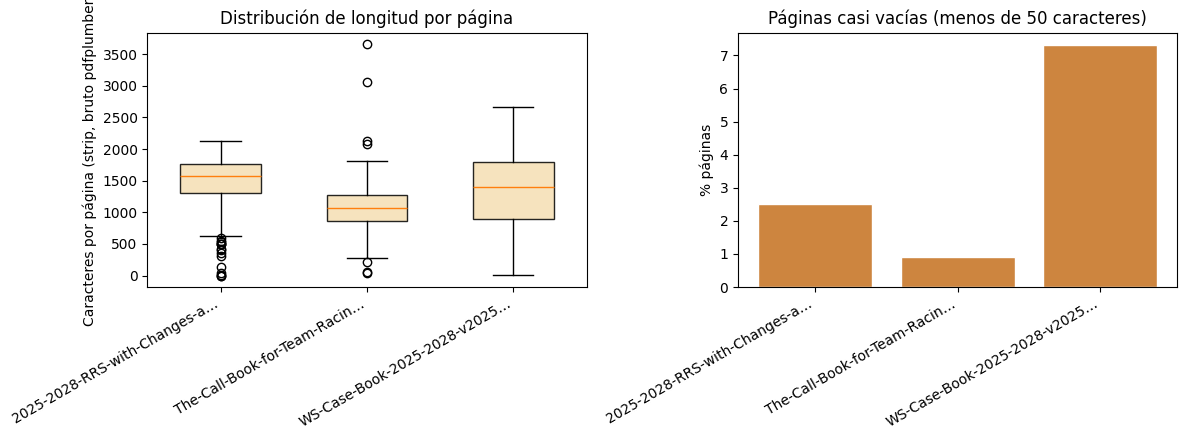

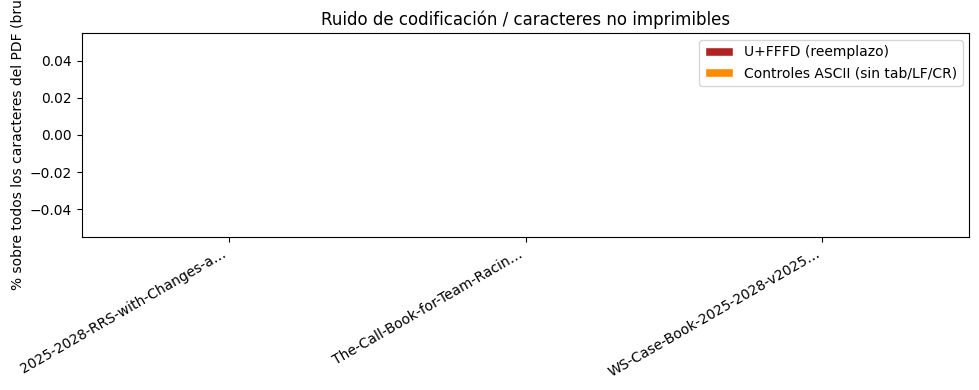

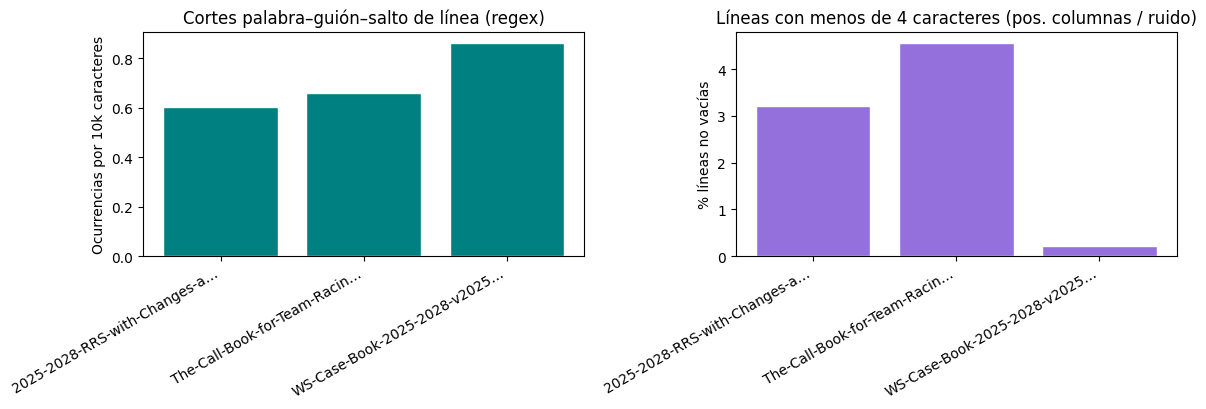

In [9]:
import re

import matplotlib.pyplot as plt
import numpy as np

if "corpus_docs" not in dir() or not corpus_docs:
    raise RuntimeError("Ejecutá primero la celda que construye corpus_docs.")

UMBRAL_PAGINA_VACIA = 50
SHORT_LINE_CHARS = 4
SCALE_10K = 10_000

RE_HYPHEN_LINE = re.compile(r"[A-Za-z]{2,}-\s*\r?\n\s*[A-Za-z]")


def texto_bruto_doc(pages: list[tuple[int, str]]) -> str:
    return "\n".join(t for _, t in sorted(pages, key=lambda x: x[0]))


def contar_controles_excl_nt(texto: str) -> int:
    return sum(
        1
        for c in texto
        if ord(c) < 32 and c not in "\n\r\t"
    )


def pct_lineas_muy_cortas(texto: str, max_len: int) -> float:
    lineas = [ln.strip() for ln in texto.splitlines() if ln.strip()]
    if not lineas:
        return 0.0
    cortas = sum(1 for ln in lineas if len(ln) < max_len)
    return 100.0 * cortas / len(lineas)


docs_sorted = sorted(corpus_docs.items())
labels_short = [name[:28] + "…" if len(name) > 28 else name for name, _ in docs_sorted]

por_doc_lens: list[list[int]] = []
por_doc_pct_vacias: list[float] = []
por_doc_pct_repl: list[float] = []
por_doc_pct_ctrl: list[float] = []
por_doc_hyp10k: list[float] = []
por_doc_shortln: list[float] = []

for _fname, pages in docs_sorted:
    lens_pag: list[int] = []
    n_vacias = 0
    for _pn, raw in pages:
        s = raw.strip()
        lp = len(s)
        lens_pag.append(lp)
        if lp < UMBRAL_PAGINA_VACIA:
            n_vacias += 1
    por_doc_lens.append(lens_pag)
    n_p = len(pages)
    por_doc_pct_vacias.append(100.0 * n_vacias / n_p if n_p else 0.0)

    agregado = texto_bruto_doc(pages)
    ntot = len(agregado)
    n_repl = agregado.count("\ufffd")
    n_ctrl = contar_controles_excl_nt(agregado)
    por_doc_pct_repl.append(100.0 * n_repl / ntot if ntot else 0.0)
    por_doc_pct_ctrl.append(100.0 * n_ctrl / ntot if ntot else 0.0)

    n_hyp = len(RE_HYPHEN_LINE.findall(agregado))
    por_doc_hyp10k.append(
        SCALE_10K * n_hyp / ntot if ntot else 0.0
    )
    por_doc_shortln.append(
        pct_lineas_muy_cortas(agregado, SHORT_LINE_CHARS)
    )

print(
    f"Umbral página casi vacía: {UMBRAL_PAGINA_VACIA} caracteres (strip). "
    f"Línea corta: menos de {SHORT_LINE_CHARS} caracteres no vacíos.\n"
)
print("documento | % pág. vacías | % U+FFFD | % ctrl | guión+NL /10k | % líneas cortas")
print("-" * 88)
for i, (fname, _) in enumerate(docs_sorted):
    print(
        f"{fname[:36]:<36} | {por_doc_pct_vacias[i]:5.2f} | "
        f"{por_doc_pct_repl[i]:6.4f} | {por_doc_pct_ctrl[i]:6.4f} | "
        f"{por_doc_hyp10k[i]:8.2f} | {por_doc_shortln[i]:6.2f}"
    )

# --- 1) Longitud por página (bruto) + % páginas casi vacías
por_doc_lens_plot = [xs if xs else [0.0] for xs in por_doc_lens]
pos = np.arange(1, len(docs_sorted) + 1)
fig1, (ax_box, ax_v) = plt.subplots(1, 2, figsize=(12, 4.5))
bp = ax_box.boxplot(
    por_doc_lens_plot,
    positions=pos,
    widths=0.55,
    patch_artist=True,
    showfliers=True,
)
for patch in bp["boxes"]:
    patch.set_facecolor("wheat")
    patch.set_alpha(0.85)
ax_box.set_xticks(pos)
ax_box.set_xticklabels(labels_short, rotation=30, ha="right")
ax_box.set_ylabel("Caracteres por página (strip, bruto pdfplumber)")
ax_box.set_title("Distribución de longitud por página")
ax_v.bar(pos, por_doc_pct_vacias, color="peru", edgecolor="white")
ax_v.axhline(0, color="gray", linewidth=0.5)
ax_v.set_xticks(pos)
ax_v.set_xticklabels(labels_short, rotation=30, ha="right")
ax_v.set_ylabel("% páginas")
ax_v.set_title(
    f'Páginas casi vacías (menos de {UMBRAL_PAGINA_VACIA} caracteres)'
)
fig1.tight_layout()
plt.show()

# --- 2) Caracteres problemáticos (% del total del doc)
fig2, ax2 = plt.subplots(figsize=(10, 4.0))
w = 0.36
ax2.bar(
    pos - w / 2,
    por_doc_pct_repl,
    width=w,
    label="U+FFFD (reemplazo)",
    color="firebrick",
    edgecolor="white",
)
ax2.bar(
    pos + w / 2,
    por_doc_pct_ctrl,
    width=w,
    label="Controles ASCII (sin tab/LF/CR)",
    color="darkorange",
    edgecolor="white",
)
ax2.set_xticks(pos)
ax2.set_xticklabels(labels_short, rotation=30, ha="right")
ax2.set_ylabel("% sobre todos los caracteres del PDF (bruto)")
ax2.set_title("Ruido de codificación / caracteres no imprimibles")
ax2.legend()
fig2.tight_layout()
plt.show()

# --- 3) Artefactos: guión+NL y líneas muy cortas
fig3, (ax_h, ax_s) = plt.subplots(1, 2, figsize=(12, 4.2))
ax_h.bar(pos, por_doc_hyp10k, color="teal", edgecolor="white")
ax_h.set_xticks(pos)
ax_h.set_xticklabels(labels_short, rotation=30, ha="right")
ax_h.set_ylabel("Ocurrencias por 10k caracteres")
ax_h.set_title("Cortes palabra–guión–salto de línea (regex)")
ax_s.bar(pos, por_doc_shortln, color="mediumpurple", edgecolor="white")
ax_s.set_xticks(pos)
ax_s.set_xticklabels(labels_short, rotation=30, ha="right")
ax_s.set_ylabel("% líneas no vacías")
ax_s.set_title(
    f"Líneas con menos de {SHORT_LINE_CHARS} caracteres (pos. columnas / ruido)"
)
fig3.tight_layout()
plt.show()

## Cobertura para recuperación híbrida

Vistas orientadas a la mezcla **léxica** (solapamiento de términos / IDF aproximado, como `LexicalRetriever` en `regatas_assistant/rag/retriever.py`) y **densa** (embeddings sobre el texto del fragmento). Los fragmentos se generan con **`load_corpus_chunks`** y los mismos **`chunk_size` / `chunk_overlap`** que `Settings` (por defecto 900 / 120 caracteres), sobre los PDF de `corpus/` respecto de **`REPO`**.

1. **Riqueza léxica por fragmento:** cantidad de términos léxicos por chunk (regex de 3+ letras, insensible a mayúsculas, alineada al retriever). Comparación entre PDFs de origen (`TextChunk.source_file`).

2. **Rareza documental (df) por PDF y global:** para cada documento, el **df** cuenta en cuántos chunks **de ese mismo archivo** aparece cada término (hapax / raro / frecuente con los mismos umbrales). Una barra apilada por PDF permite comparar dispersión léxica entre fuentes; la barra **global** agrega todos los chunks del índice (como en producción con varios PDF).

3. **Proxy de cobertura para embeddings:** longitud del fragmento en **tokens Qwen** (mismo criterio que la sección de 512 tokens). Indica cuánto texto aporta cada chunk a un encoder con límite de contexto típico (p. ej. truncado a 512); la línea vertical marca ese techo ilustrativo.

**Prerrequisitos:** la celda de código agrega la raíz del repo a `sys.path` (busca `regatas_assistant/` y `app.py`) para poder importar el paquete aunque el kernel tenga otro directorio de trabajo. Si ya ejecutaste la celda inicial, también usa **`REPO`**. Para el tokenizer, ejecutá antes **Cobertura con ventana de 512 tokens** o dejá que la celda siguiente cargue `AutoTokenizer` si hace falta.

Chunks: 1,247  |  chunk_size=900  overlap=120 (caracteres)
Vocabulario léxico global: 4,164 términos (3+ letras, por chunk)
  hapax (df=1): 1,557 (37.4%)
  raro (df 2–5): 1,296 (31.1%)
  frecuente (df≥6): 1,311 (31.5%)

archivo | media lex/chunk | media tokens Qwen/chunk
------------------------------------------------------------------------
2025-2028-RRS-with-Changes-and-Correct |     55.4 |    172.0
The-Call-Book-for-Team-Racing-2025-202 |     52.6 |    169.5
WS-Case-Book-2025-2028-v2025-07.pdf    |     54.6 |    160.7


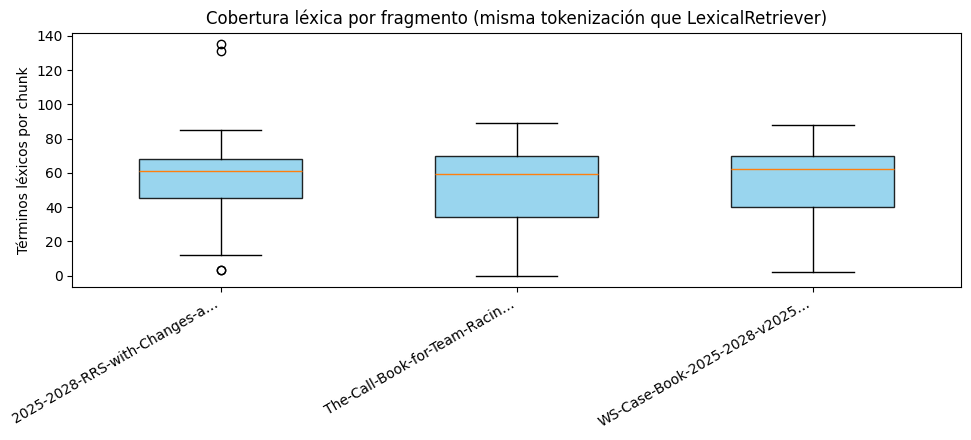

Rareza léxica por documento (df = nº de chunks del mismo PDF que contienen el término):
archivo | vocab | hapax | raro | frecuente
------------------------------------------------------------------------
2025-2028-RRS-with-Changes-and-Correct | 2,605 | 1,101 (42.3%) |   884 |   620
The-Call-Book-for-Team-Racing-2025-202 | 1,186 |   496 (41.8%) |   373 |   317
WS-Case-Book-2025-2028-v2025-07.pdf    | 2,797 |   977 (34.9%) |   911 |   909


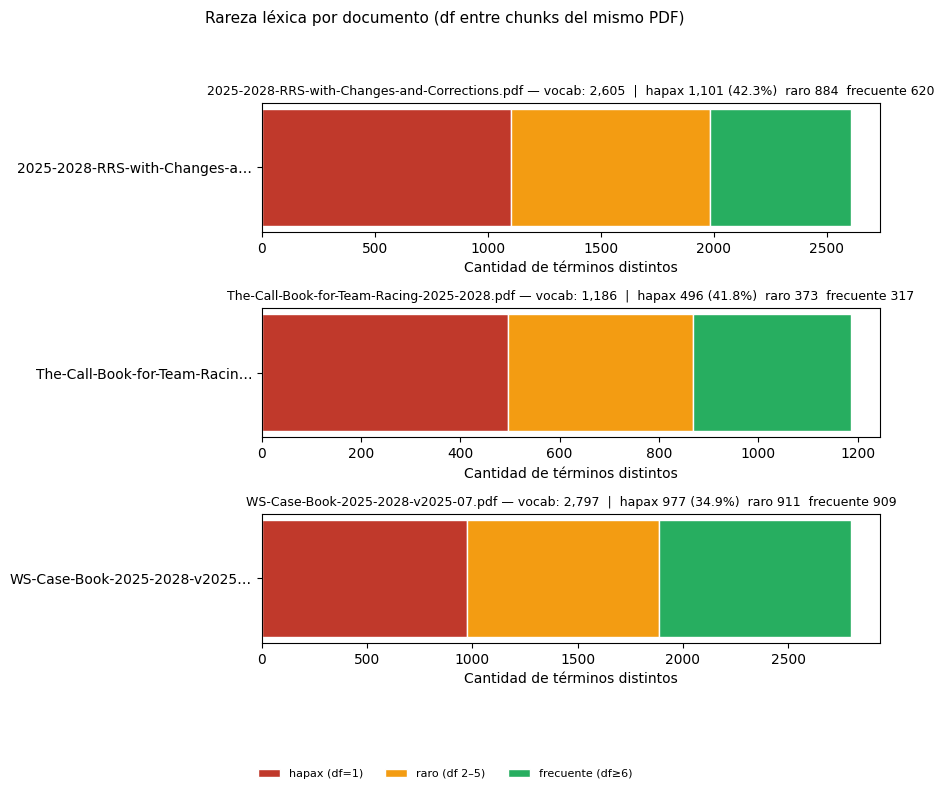

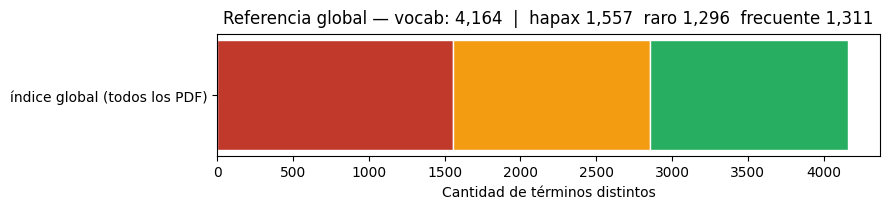

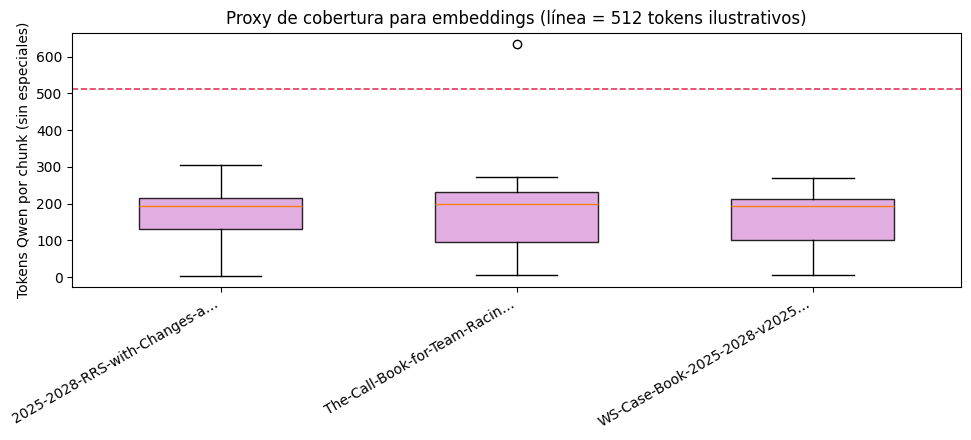

In [10]:
import os
import re
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer

_cwd = Path.cwd().resolve()
if "REPO" in dir():
    _root = Path(REPO).resolve()
else:
    _root = None
    for p in [_cwd, *_cwd.parents]:
        if (p / "regatas_assistant").is_dir() and (p / "app.py").is_file():
            _root = p
            break
    if _root is None:
        raise RuntimeError(
            "No se encontró la raíz del repo (regatas_assistant/ + app.py). "
            "Abrí el proyecto desde la carpeta del repositorio o ejecutá la celda inicial."
        )
_rp = str(_root)
if _rp not in sys.path:
    sys.path.insert(0, _rp)

from regatas_assistant.config import Settings
from regatas_assistant.ingestion import load_corpus_chunks

def tokenize_lexical(text: str) -> set[str]:
    return {t for t in re.findall(r"[a-zA-ZáéíóúñÁÉÍÓÚÑ]{3,}", text.lower())}


corpus_names = tuple(sorted(p.name for p in (_root / "corpus").glob("*.pdf")))
if not corpus_names:
    raise FileNotFoundError(f"No hay PDFs en {_root / 'corpus'}")

settings = Settings(base_dir=_root, corpus_filenames=corpus_names)
chunks = load_corpus_chunks(settings)
if not chunks:
    raise RuntimeError("No se obtuvieron fragmentos; revisá el corpus y la ingesta.")

vocabs = [tokenize_lexical(c.text) for c in chunks]
lex_counts = [len(v) for v in vocabs]

df_term: dict[str, int] = defaultdict(int)
for v in vocabs:
    for t in v:
        df_term[t] += 1

n_hapax = sum(1 for d in df_term.values() if d == 1)
n_rare = sum(1 for d in df_term.values() if 2 <= d <= 5)
n_freq = sum(1 for d in df_term.values() if d >= 6)
n_vocab = len(df_term)

by_file_lex: dict[str, list[int]] = defaultdict(list)
for c, n in zip(chunks, lex_counts):
    by_file_lex[c.source_file].append(n)

files_sorted = sorted(by_file_lex.keys())
labels_short = [n[:28] + "…" if len(n) > 28 else n for n in files_sorted]
data_lex = [by_file_lex[f] for f in files_sorted]
data_lex_plot = [xs if xs else [0] for xs in data_lex]

if "tokenizer" not in dir():
    _mid = os.environ.get("REGATAS_QWEN_MODEL_ID", "Qwen/Qwen2.5-14B-Instruct")
    tokenizer = AutoTokenizer.from_pretrained(_mid, trust_remote_code=True)
    print(f"Tokenizer Qwen cargado: {_mid}\n")

MAX_EMB_TOKS = 512
tok_lens = [
    len(tokenizer.encode(c.text, add_special_tokens=False)) for c in chunks
]
by_file_tok: dict[str, list[int]] = defaultdict(list)
for c, n in zip(chunks, tok_lens):
    by_file_tok[c.source_file].append(n)
data_tok = [by_file_tok[f] for f in files_sorted]
data_tok_plot = [xs if xs else [0] for xs in data_tok]

print(
    f"Chunks: {len(chunks):,}  |  chunk_size={settings.chunk_size}  "
    f"overlap={settings.chunk_overlap} (caracteres)\n"
    f"Vocabulario léxico global: {n_vocab:,} términos (3+ letras, por chunk)\n"
    f"  hapax (df=1): {n_hapax:,} ({100 * n_hapax / n_vocab:.1f}%)\n"
    f"  raro (df 2–5): {n_rare:,} ({100 * n_rare / n_vocab:.1f}%)\n"
    f"  frecuente (df≥6): {n_freq:,} ({100 * n_freq / n_vocab:.1f}%)\n"
)
print("archivo | media lex/chunk | media tokens Qwen/chunk")
print("-" * 72)
for fname in files_sorted:
    lx = by_file_lex[fname]
    tq = by_file_tok[fname]
    print(
        f"{fname[:38]:<38} | {np.mean(lx):8.1f} | {np.mean(tq):8.1f}"
    )

# --- 1) Términos léxicos por fragmento (ruta BM25-like)
pos = np.arange(1, len(files_sorted) + 1)
fig1, ax1 = plt.subplots(figsize=(10, 4.5))
bp = ax1.boxplot(
    data_lex_plot,
    positions=pos,
    widths=0.55,
    patch_artist=True,
    showfliers=True,
)
for patch in bp["boxes"]:
    patch.set_facecolor("skyblue")
    patch.set_alpha(0.85)
ax1.set_xticks(pos)
ax1.set_xticklabels(labels_short, rotation=30, ha="right")
ax1.set_ylabel("Términos léxicos por chunk")
ax1.set_title(
    "Cobertura léxica por fragmento (misma tokenización que LexicalRetriever)"
)
fig1.tight_layout()
plt.show()

def _rarity_counts(df_map: dict[str, int]) -> tuple[int, int, int, int]:
    n_vocab = len(df_map)
    n_h = sum(1 for d in df_map.values() if d == 1)
    n_r = sum(1 for d in df_map.values() if 2 <= d <= 5)
    n_f = sum(1 for d in df_map.values() if d >= 6)
    return n_vocab, n_h, n_r, n_f


def _df_within_file(chunks_for_file) -> dict[str, int]:
    df_local: dict[str, int] = defaultdict(int)
    for c in chunks_for_file:
        for t in tokenize_lexical(c.text):
            df_local[t] += 1
    return df_local


df_by_file: dict[str, dict[str, int]] = {}
for fname in files_sorted:
    file_chunks = [c for c in chunks if c.source_file == fname]
    df_by_file[fname] = _df_within_file(file_chunks)

print("Rareza léxica por documento (df = nº de chunks del mismo PDF que contienen el término):")
print("archivo | vocab | hapax | raro | frecuente")
print("-" * 72)
for fname in files_sorted:
    v, h, r, f = _rarity_counts(df_by_file[fname])
    pct_h = 100 * h / v if v else 0.0
    print(
        f"{fname[:38]:<38} | {v:5,} | {h:5,} ({pct_h:4.1f}%) | {r:5,} | {f:5,}"
    )

# --- 2) Rareza léxica por documento (df calculado solo entre chunks del mismo PDF)
colors = ("#c0392b", "#f39c12", "#27ae60")
n_rows = len(files_sorted)
fig2, axes2 = plt.subplots(
    n_rows,
    1,
    figsize=(9, max(2.6, 2.4 * n_rows)),
    squeeze=False,
)
from matplotlib.patches import Patch

legend_patches = [
    Patch(facecolor=c, edgecolor="white", label=lab)
    for c, lab in zip(
        colors,
        ("hapax (df=1)", "raro (df 2–5)", "frecuente (df≥6)"),
    )
]
for row, fname in enumerate(files_sorted):
    ax2 = axes2[row, 0]
    v, h, r, f = _rarity_counts(df_by_file[fname])
    left = 0.0
    for w, col in zip((h, r, f), colors):
        ax2.barh(0, w, left=left, height=0.45, color=col, edgecolor="white")
        left += w
    ax2.set_yticks([0])
    ax2.set_yticklabels([labels_short[row]])
    ax2.set_xlabel("Cantidad de términos distintos")
    ax2.set_title(
        f"{fname} — vocab: {v:,}  |  hapax {h:,} ({100 * h / v:.1f}%)  "
        f"raro {r:,}  frecuente {f:,}",
        fontsize=9,
        pad=6,
    )
axes2[0, 0].figure.suptitle(
    "Rareza léxica por documento (df entre chunks del mismo PDF)",
    y=1.02,
    fontsize=11,
)
fig2.legend(
    handles=legend_patches,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    fontsize=8,
    frameon=False,
)
fig2.tight_layout(rect=(0, 0.06, 1, 0.98))
plt.show()

# --- 2b) Vista global del índice completo (referencia)
fig2g, ax2g = plt.subplots(figsize=(9, 2.2))
left = 0.0
for w, col in zip((n_hapax, n_rare, n_freq), colors):
    ax2g.barh(0, w, left=left, height=0.45, color=col, edgecolor="white")
    left += w
ax2g.set_yticks([0])
ax2g.set_yticklabels(["índice global (todos los PDF)"])
ax2g.set_xlabel("Cantidad de términos distintos")
ax2g.set_title(
    f"Referencia global — vocab: {n_vocab:,}  |  hapax {n_hapax:,}  "
    f"raro {n_rare:,}  frecuente {n_freq:,}",
    pad=8,
)
fig2g.tight_layout()
plt.show()

# --- 3) Tokens por chunk (proxy ruta semántica / truncado de encoder)
fig3, ax3 = plt.subplots(figsize=(10, 4.5))
bp3 = ax3.boxplot(
    data_tok_plot,
    positions=pos,
    widths=0.55,
    patch_artist=True,
    showfliers=True,
)
for patch in bp3["boxes"]:
    patch.set_facecolor("plum")
    patch.set_alpha(0.85)
ax3.axhline(MAX_EMB_TOKS, color="crimson", linestyle="--", linewidth=1.2, alpha=0.85)
ax3.set_xticks(pos)
ax3.set_xticklabels(labels_short, rotation=30, ha="right")
ax3.set_ylabel("Tokens Qwen por chunk (sin especiales)")
ax3.set_title(
    f"Proxy de cobertura para embeddings (línea = {MAX_EMB_TOKS} tokens ilustrativos)"
)
fig3.tight_layout()
plt.show()


## Frecuencia de términos por documento (corpus indexado)

Para cada PDF del índice (mismos **`TextChunk`** que la sección de recuperación híbrida: `load_corpus_chunks`), se cuentan apariciones de **tokens léxicos** (palabras de 3+ letras, igual que el retriever) y se muestran los **más frecuentes** por archivo.

Se excluyen las **stopwords** de `regatas_assistant/stopwords_en.txt` para que el gráfico destaque vocabulario normativo en lugar de conectores en inglés.

**Prerrequisito:** ejecutar antes la celda de **Cobertura para recuperación híbrida** (define `chunks` y resuelve imports), o la celda siguiente es autocontenida si se ejecuta sola.

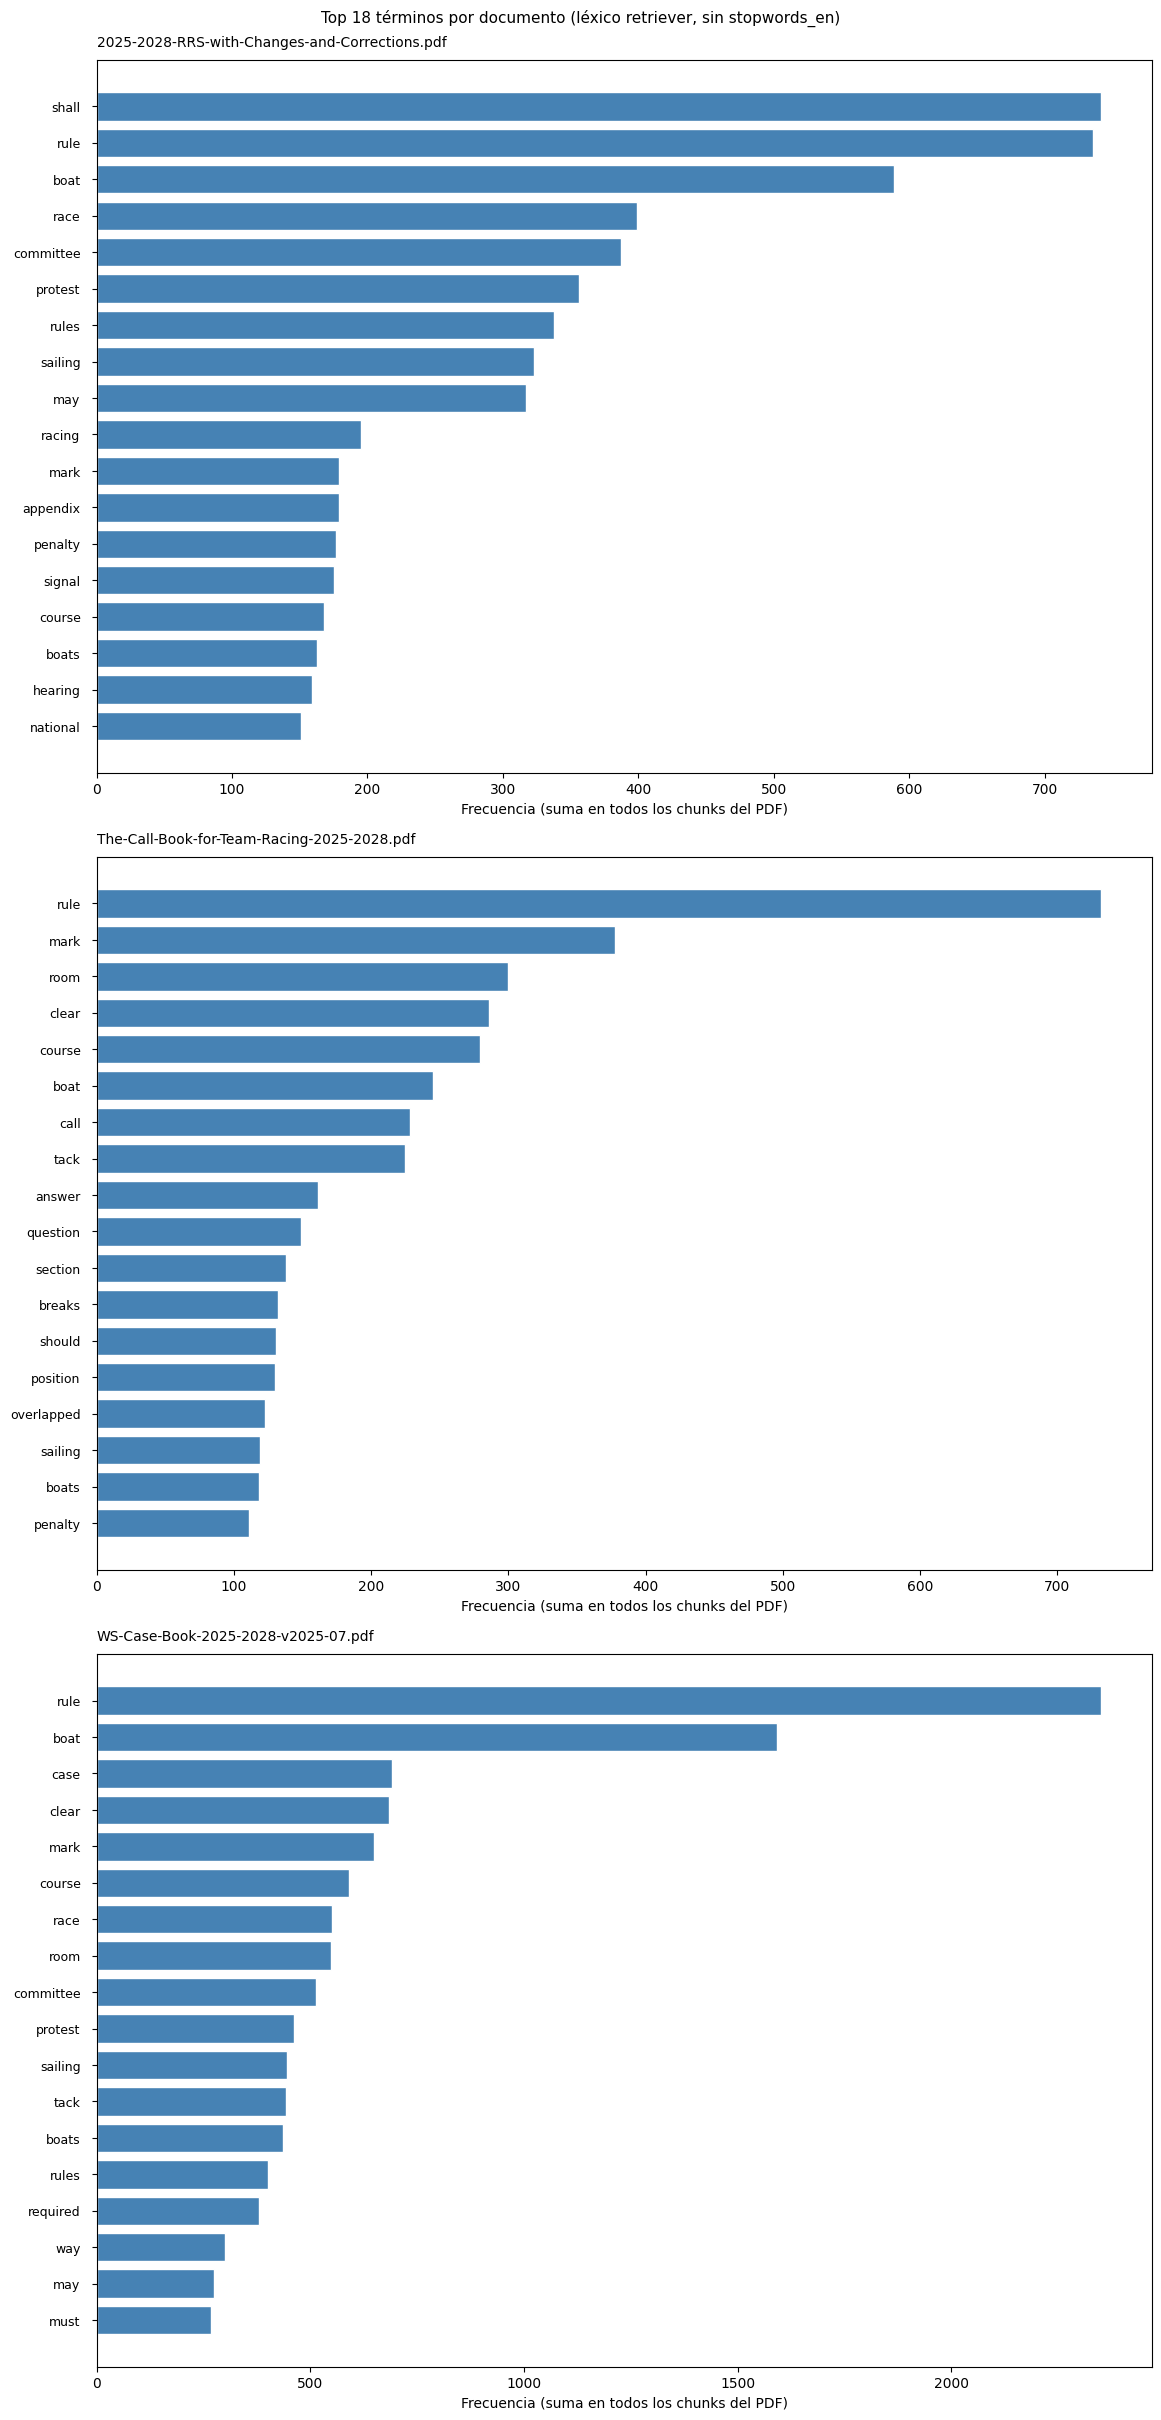

In [57]:
import os
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
if "chunks" in dir() and chunks and "settings" in dir():
    _root = Path(settings.base_dir).resolve()
else:
    _root = None
    for p in [_cwd, *_cwd.parents]:
        if (p / "regatas_assistant").is_dir() and (p / "app.py").is_file():
            _root = p
            break
    if _root is None:
        raise RuntimeError("No se encontró la raíz del repo.")
    _rp = str(_root)
    if _rp not in sys.path:
        sys.path.insert(0, _rp)
    from regatas_assistant.config import Settings
    from regatas_assistant.ingestion import load_corpus_chunks

    _names = tuple(sorted(p.name for p in (_root / "corpus").glob("*.pdf")))
    settings = Settings(base_dir=_root, corpus_filenames=_names)
    chunks = load_corpus_chunks(settings)
    if not chunks:
        raise RuntimeError("Sin chunks; revisá corpus/.")

TOP_TERMS = 18


def lexical_tokens(text: str) -> list[str]:
    return re.findall(r"[a-zA-ZáéíóúñÁÉÍÓÚÑ]{3,}", text.lower())


_sw_path = _root / "regatas_assistant" / "stopwords_en.txt"
_stop: set[str] = set()
if _sw_path.is_file():
    for line in _sw_path.read_text(encoding="utf-8").splitlines():
        w = line.strip().lower()
        if w and not w.lstrip().startswith("#"):
            _stop.add(w)

by_file: dict[str, Counter[str]] = defaultdict(Counter)
for c in chunks:
    for tok in lexical_tokens(c.text):
        if tok not in _stop:
            by_file[c.source_file][tok] += 1

def _fmt_eje_y(t: str, max_chars: int = 28) -> str:
    t = str(t)
    return t if len(t) <= max_chars else t[: max_chars - 1] + "…"


files_ord = sorted(by_file.keys())
n = len(files_ord)
# Altura por panel: espacio por fila de término + título y eje X (evita solapamiento en Y)
_inch_por_termino = 0.36
_alt_panel = TOP_TERMS * _inch_por_termino + 1.35
fig_h = n * _alt_panel + 0.6
fig, axes = plt.subplots(
    n,
    1,
    figsize=(11.5, fig_h),
    squeeze=False,
    constrained_layout=True,
)
for ax, fname in zip(axes.flat, files_ord):
    ctr = by_file[fname]
    top = ctr.most_common(TOP_TERMS)
    if not top:
        ax.set_title(fname[:52] + ("…" if len(fname) > 52 else ""), loc="left", fontsize=10)
        ax.text(0.5, 0.5, "(sin términos tras filtros)", ha="center", va="center")
        ax.set_axis_off()
        continue
    terms, counts = zip(*top)
    y = range(len(terms))
    ax.barh(y, counts, color="steelblue", edgecolor="white", height=0.78)
    ax.set_yticks(list(y))
    ax.set_yticklabels([_fmt_eje_y(t) for t in terms], fontsize=9)
    ax.tick_params(axis="y", pad=8)
    ax.invert_yaxis()
    ax.set_xlabel("Frecuencia (suma en todos los chunks del PDF)")
    ax.set_title(
        (fname[:52] + "…") if len(fname) > 52 else fname,
        loc="left",
        fontsize=10,
        pad=10,
    )
fig.suptitle(
    f"Top {TOP_TERMS} términos por documento (léxico retriever, sin stopwords_en)",
    fontsize=11,
)
plt.show()